In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [7]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72,74.0
1,female,group C,some college,standard,completed,69.0,90,88.0
2,female,group B,master's degree,standard,none,90.0,95,93.0
3,male,group A,associate's degree,free/reduced,none,NaN,57,44.0
4,male,group C,some college,standard,none,76.0,78,75.0


In [9]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     1
reading score                  0
writing score                  1
dtype: int64

In [10]:
df.columns = df.columns.str.strip()
df['math score'] = df['math score'].fillna(df['math score'].mean())
df['writing score'] = df['writing score'].fillna(df['writing score'].mean())
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [11]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.000000,72,74.0
1,female,group C,some college,standard,completed,69.000000,90,88.0
2,female,group B,master's degree,standard,none,90.000000,95,93.0
3,male,group A,associate's degree,free/reduced,none,66.108108,57,44.0
4,male,group C,some college,standard,none,76.000000,78,75.0


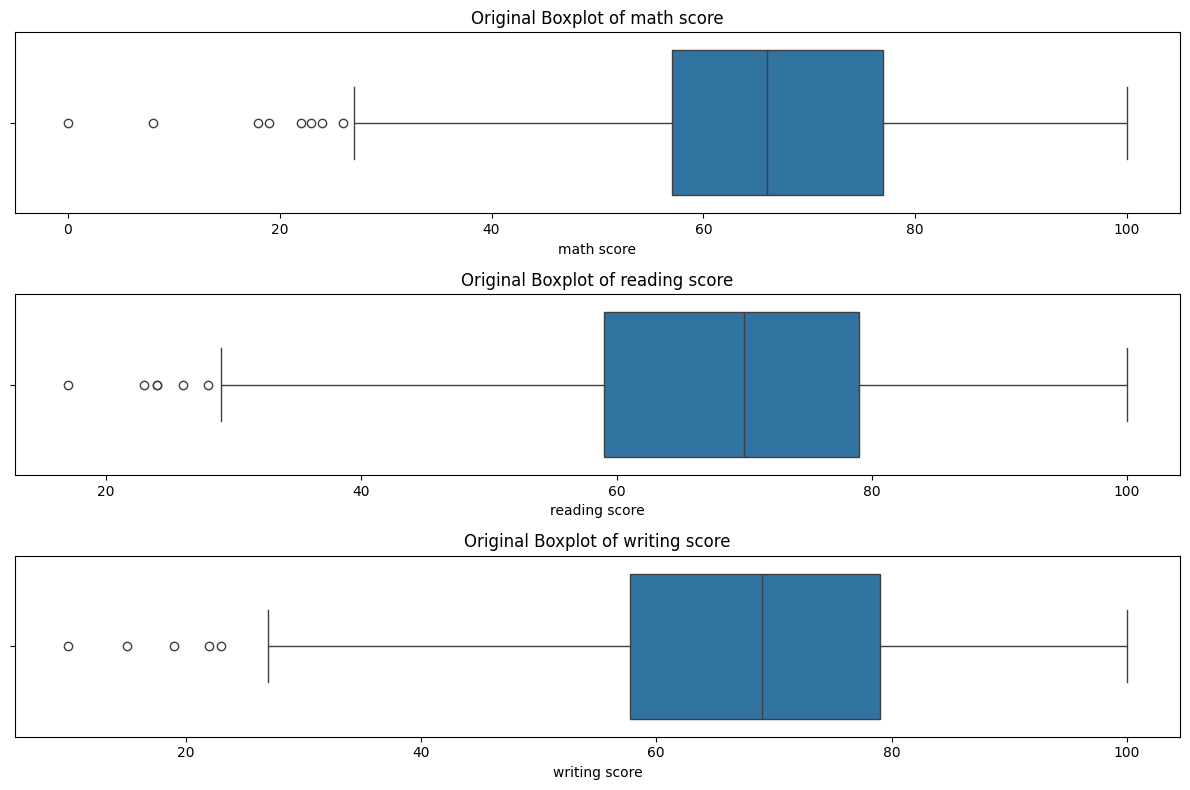

In [12]:
# Step 4: Define numeric columns
numeric_cols = ['math score', 'reading score', 'writing score']

# Step 5: Plot original boxplots
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 1, i)
    sns.boxplot(x=df[col])
    plt.title(f'Original Boxplot of {col}')
plt.tight_layout()
plt.show()

In [13]:
# Step 6: Remove outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

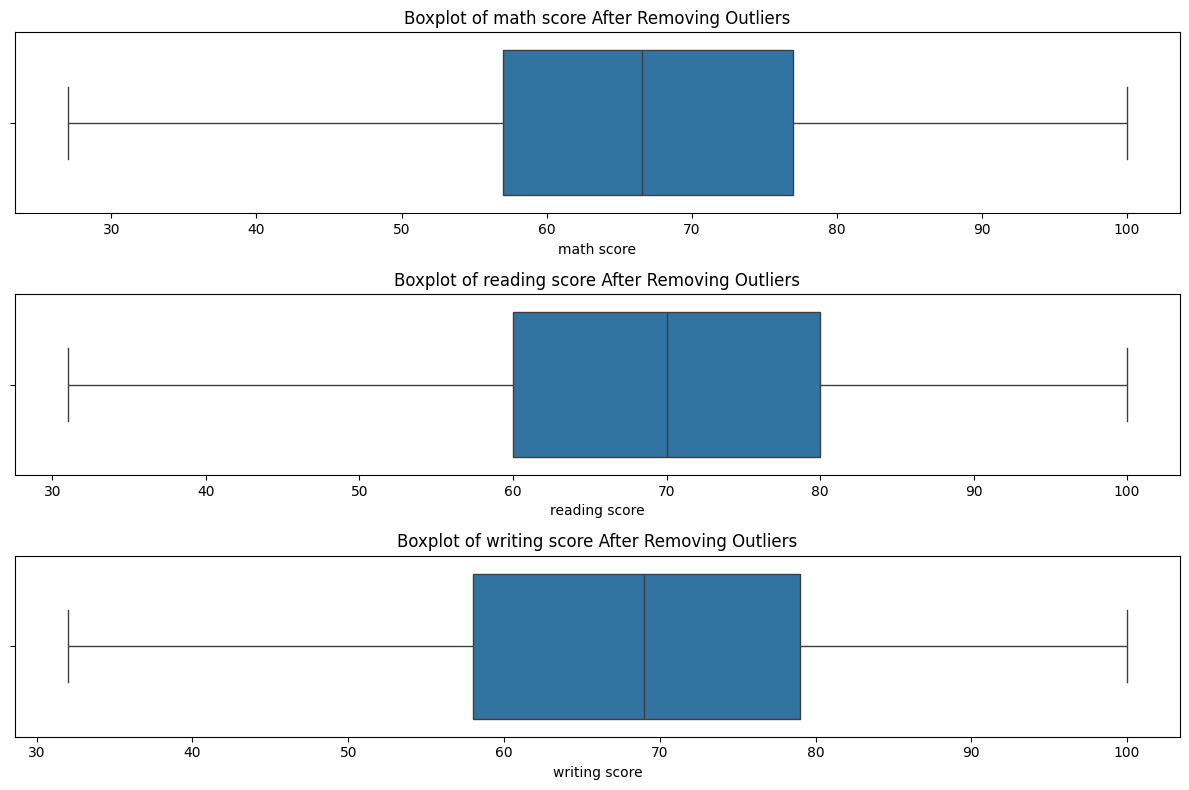

In [14]:
# Step 7: Plot boxplots after removing outliers
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 1, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} After Removing Outliers')
plt.tight_layout()
plt.show()

Before transformation skewness: -0.02747222088168531
After transformation skewness: -0.6467415868285542


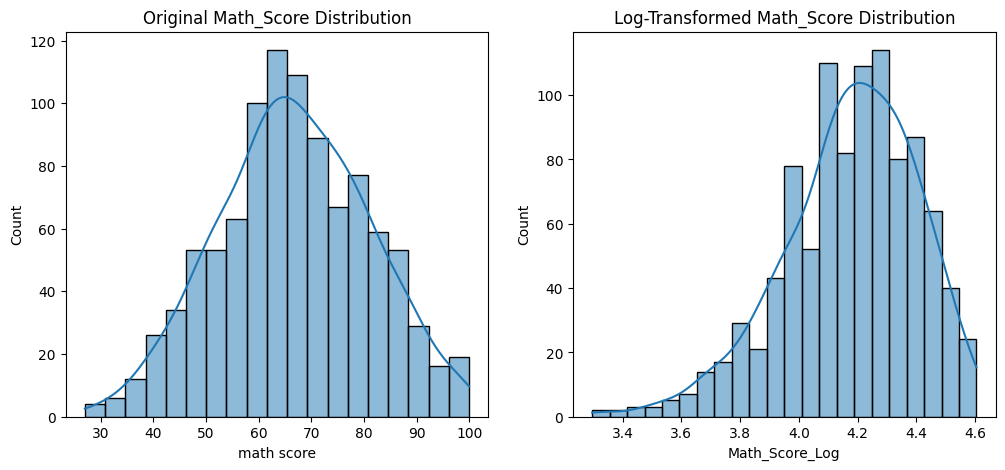

In [19]:
# Step 7: Check skewness before transformation
print("Before transformation skewness:", df['math score'].skew())

# Apply log transformation
df['Math_Score_Log'] = np.log(df['math score'])

# Check skewness after transformation
print("After transformation skewness:", df['Math_Score_Log'].skew())

# Plot distribution before and after
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['math score'], kde=True)
plt.title('Original Math_Score Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['Math_Score_Log'], kde=True)
plt.title('Log-Transformed Math_Score Distribution')

plt.show()
